## Part 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment is ready!")

Environment is ready!


## Part 2

In [3]:
df = pd.read_csv("stayeasy_guests.csv")

In [4]:
df.head()

,CustomerID,Age,Gender,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,1532,31.0,Male,Silver,NaN,8,2.9,False,123,High
1,1475,NaN,NaN,Bronze,243.14,3,3.2,True,13,Medium
2,1540,60.0,Male,Gold,272.84,8,4.1,No,137,Medium
3,1496,35.0,Female,Bronze,NaN,6,4.2,True,88,High
4,1350,42.0,Female,Bronze,244.12,4,4.4,True,33,High


In [5]:
df.shape

(459, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                459 non-null    int64  
 1   Age                       436 non-null    str    
 2   Gender                    446 non-null    str    
 3   Membership Type           459 non-null    str    
 4   Total Spend               440 non-null    str    
 5   Items Purchased           459 non-null    int64  
 6   Average Rating            431 non-null    float64
 7   Discount Applied          459 non-null    str    
 8   Days Since Last Purchase  459 non-null    int64  
 9   Satisfaction Level        437 non-null    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 36.0 KB


In [7]:
df.describe()

,CustomerID,Items Purchased,Average Rating,Days Since Last Purchase
count,459.000000,459.000000,431.000000,459.000000
mean,1332.614379,5.686275,4.002552,89.718954
std,130.128378,4.562239,0.629705,52.332426
min,1108.000000,0.000000,2.300000,-10.000000
25%,1220.500000,4.000000,3.600000,43.000000
50%,1332.000000,5.000000,4.000000,90.000000
75%,1444.500000,7.000000,4.400000,136.000000
max,1557.000000,87.000000,9.500000,179.000000


Датасет містить 459 записів  
Типи даних, що використовуються: float64(1), int64(3), str(6)  
Перші спостереження:  велика кількість NaN значень, різних слів на позначення True і False, позначення сум з викорситанням знака $ і без нього, некоректні типи даних для Age (має бути int), Total Spend (має бути float), Discount Applied (має бути bool)


## Part 3

In [8]:
missing_total = df.isna().sum().sum()
print(f'Missing total: {missing_total}')
df.isna().sum()

Missing total: 105


CustomerID                   0
Age                         23
Gender                      13
Membership Type              0
Total Spend                 19
Items Purchased              0
Average Rating              28
Discount Applied             0
Days Since Last Purchase     0
Satisfaction Level          22
dtype: int64

In [9]:
print(f"Total duplicates: {df.duplicated().sum()}")

Total duplicates: 9


In [10]:
df.describe(include='all')

,CustomerID,Age,Gender,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,459.000000,436,446,459,440,459.000000,431.000000,459,459.000000,437
unique,NaN,52,2,3,427,NaN,NaN,6,NaN,3
top,NaN,35.0,Male,Bronze,137.68,NaN,NaN,False,NaN,Medium
freq,NaN,16,223,233,2,NaN,NaN,269,NaN,202
mean,1332.614379,NaN,NaN,NaN,NaN,5.686275,4.002552,NaN,89.718954,NaN
std,130.128378,NaN,NaN,NaN,NaN,4.562239,0.629705,NaN,52.332426,NaN
min,1108.000000,NaN,NaN,NaN,NaN,0.000000,2.300000,NaN,-10.000000,NaN
25%,1220.500000,NaN,NaN,NaN,NaN,4.000000,3.600000,NaN,43.000000,NaN
50%,1332.000000,NaN,NaN,NaN,NaN,5.000000,4.000000,NaN,90.000000,NaN
75%,1444.500000,NaN,NaN,NaN,NaN,7.000000,4.400000,NaN,136.000000,NaN


In [11]:
print(df['Age'].unique())
print(df['Gender'].value_counts())
print(df['Membership Type'].value_counts())
print(df['Discount Applied'].value_counts())
print(df['Satisfaction Level'].value_counts())

<StringArray>
[   '31.0',       nan,    '60.0',    '35.0',    '42.0',    '54.0',    '44.0',
    '47.0',    '65.0',    '40.0',    '43.0',    '50.0',    '49.0',    '61.0',
    '57.0',    '52.0',    '21.0',    '28.0',    '19.0',    '30.0',    '26.0',
    '32.0',    '23.0',    '39.0',    '38.0',    '18.0',    '33.0',    '62.0',
    '48.0',    '45.0', 'unknown',    '29.0',      '--',    '20.0',    '37.0',
    '41.0',    '63.0',    '24.0',    '25.0',     '141',    '59.0',    '55.0',
    '51.0',    '27.0',    '36.0',    '34.0',    '64.0',    '22.0',    '53.0',
    '46.0',    '58.0',      '-4',    '56.0']
Length: 53, dtype: str
Gender
Male      223
Female    223
Name: count, dtype: int64
Membership Type
Bronze    233
Silver    149
Gold       77
Name: count, dtype: int64
Discount Applied
False    269
True     148
No        18
1         11
0         11
Yes        2
Name: count, dtype: int64
Satisfaction Level
Medium    202
High      181
Low        54
Name: count, dtype: int64


Які проблеми вдалося знайти?  
- в колонці Age трапляються некоректі від'ємні, занадто великі, NaN значення, а також вона є типом str
- в колонці Gender велика кількість значень NaN
- в колонці Total Spend є значення зі знаком $ і без, трапляються від'ємні та NaN значення а також вона є типом str
- в колонці Average Rating бувають значення NaN та більші за 5
- в колонці Discount Applied використовуються різні слова на позначення True та False, а також вона є типом str
- в колонці Days Since Last Purchase бувають від'ємні значення
- в колонці Satisfaction Level трапляються NaN значення  

Всі ці проблеми можуть вплинути на результати аналізу

## Part 4

In [12]:
print(df.shape)
df.drop_duplicates(inplace=True)
print(df.shape)

(459, 10)
(450, 10)


In [13]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df.loc[(df['Age'] <= 0) | (df['Age'] >= 100), 'Age'] = np.nan

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Age'] = df['Age'].astype(int)

print(df['Age'].describe())
print(df['Age'].head())

count    450.000000
mean      40.686667
std       13.224195
min       18.000000
25%       30.000000
50%       40.000000
75%       51.000000
max       65.000000
Name: Age, dtype: float64
0    31
1    40
2    60
3    35
4    42
Name: Age, dtype: int64


In [14]:
df['Gender'] = df['Gender'].fillna('Unknown')
df['Gender'].describe()

count        450
unique         3
top       Female
freq         219
Name: Gender, dtype: object

In [15]:
df['Total Spend'] = (
    df['Total Spend'].astype(str)
      .str.replace('$', '', regex=False)
      .str.replace(',', '', regex=False)
)

df['Total Spend'] = pd.to_numeric(df['Total Spend'], errors='coerce')
df['Total Spend'] = df['Total Spend'].fillna(df['Total Spend'].median())
df = df[df['Total Spend'] >= 0].copy()

df = df[df['CustomerID'] != 1453].copy() ## 99999.99 total spend for 3 purchases
df = df[df['CustomerID'] != 1289].copy() ## small spending on a lot of goods

df['Total Spend'] = df['Total Spend'].astype(float)
df['Total Spend'].describe()

count     447.000000
mean      252.864228
std       180.631690
min        15.780000
25%       127.660000
50%       204.260000
75%       331.720000
max      1476.800000
Name: Total Spend, dtype: float64

In [16]:
df.loc[(df['Average Rating'] < 0) | (df['Average Rating'] > 5), 'Average Rating'] = np.nan
df['Average Rating'] = df['Average Rating'].fillna(df['Average Rating'].median())
df['Average Rating'].describe()

count    447.000000
mean       3.987472
std        0.551821
min        2.300000
25%        3.600000
50%        4.000000
75%        4.400000
max        5.000000
Name: Average Rating, dtype: float64

In [17]:
print(df['Discount Applied'].unique())

df['Discount Applied'] = df['Discount Applied'].replace(
    {'Yes': True, '1': True, 'No': False, '0': False,
     'True': True, 'False': False}
)

df['Discount Applied'] = df['Discount Applied'].astype(bool)

print(df['Discount Applied'].unique())
df['Discount Applied'].describe()

<StringArray>
['False', 'True', 'No', '1', '0', 'Yes']
Length: 6, dtype: str
[False  True]


count       447
unique        2
top       False
freq        291
Name: Discount Applied, dtype: object

In [18]:
(df['Days Since Last Purchase'] < 0).sum()

df = df[df['Days Since Last Purchase'] >= 0].copy()

df['Days Since Last Purchase'].describe()

count    446.000000
mean      89.533632
std       52.094965
min        0.000000
25%       43.000000
50%       88.500000
75%      135.000000
max      179.000000
Name: Days Since Last Purchase, dtype: float64

In [19]:
print(df['Satisfaction Level'].isna().sum())
df = df.dropna(subset=['Satisfaction Level'])
print(df['Satisfaction Level'].isna().sum())

21
0


In [20]:
missing_total = df.isna().sum().sum()
print(f'Missing total: {missing_total}')
df.isna().sum()

Missing total: 0


CustomerID                  0
Age                         0
Gender                      0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

In [21]:
print(f"Total duplicates: {df.duplicated().sum()}")

Total duplicates: 0


In [22]:
print(df['Age'].unique())
print(df['Gender'].value_counts())
print(df['Membership Type'].value_counts())
print(df['Discount Applied'].value_counts())
print(df['Satisfaction Level'].value_counts())

[31 40 60 35 42 44 47 65 54 43 50 49 61 57 52 21 28 19 30 32 23 39 38 18
 48 45 29 62 20 37 41 26 63 24 25 59 55 33 51 27 36 34 64 22 53 46 58 56]
Gender
Female     209
Male       203
Unknown     13
Name: count, dtype: int64
Membership Type
Bronze    216
Silver    137
Gold       72
Name: count, dtype: int64
Discount Applied
False    280
True     145
Name: count, dtype: int64
Satisfaction Level
Medium    198
High      175
Low        52
Name: count, dtype: int64


In [23]:
df.describe(include='all')

,CustomerID,Age,Gender,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
count,425.000000,425.000000,425,425,425.000000,425.000000,425.000000,425,425.000000,425
unique,NaN,NaN,3,3,NaN,NaN,NaN,2,NaN,3
top,NaN,NaN,Female,Bronze,NaN,NaN,NaN,False,NaN,Medium
freq,NaN,NaN,209,216,NaN,NaN,NaN,280,NaN,198
mean,1334.858824,40.489412,NaN,NaN,255.894565,5.508235,3.983294,NaN,89.381176,NaN
std,129.987949,13.252109,NaN,NaN,183.614065,2.505758,0.546195,NaN,52.348214,NaN
min,1108.000000,18.000000,NaN,NaN,15.780000,0.000000,2.500000,NaN,0.000000,NaN
25%,1223.000000,30.000000,NaN,NaN,129.410000,4.000000,3.600000,NaN,42.000000,NaN
50%,1335.000000,40.000000,NaN,NaN,204.260000,5.000000,4.000000,NaN,88.000000,NaN
75%,1447.000000,50.000000,NaN,NaN,334.680000,7.000000,4.400000,NaN,135.000000,NaN


In [24]:
df.shape

(425, 10)

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 425 entries, 0 to 458
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                425 non-null    int64  
 1   Age                       425 non-null    int64  
 2   Gender                    425 non-null    str    
 3   Membership Type           425 non-null    str    
 4   Total Spend               425 non-null    float64
 5   Items Purchased           425 non-null    int64  
 6   Average Rating            425 non-null    float64
 7   Discount Applied          425 non-null    bool   
 8   Days Since Last Purchase  425 non-null    int64  
 9   Satisfaction Level        425 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(3)
memory usage: 33.6 KB


## Part 5

In [26]:
stats = df.select_dtypes(include='number').agg(['mean', 'median', 'min', 'max'])

print(stats)

         CustomerID        Age  Total Spend  Items Purchased  Average Rating  \
mean    1334.858824  40.489412   255.894565         5.508235        3.983294   
median  1335.000000  40.000000   204.260000         5.000000        4.000000   
min     1108.000000  18.000000    15.780000         0.000000        2.500000   
max     1557.000000  65.000000  1476.800000        13.000000        5.000000   

        Days Since Last Purchase  
mean                   89.381176  
median                 88.000000  
min                     0.000000  
max                   179.000000  


Які показники вас найбільше здивували? - всі характеристики є доволі типовими, оскільки було проведено глибоке очищення датасету. Колонка Total Spend могла мати інші значення, якби ми не видалили аномалію з 99999 за 3 покупки. Так само Items Purchased 

Які характеристики даних можна визначити вже на цьому етапі? - можна визначити середній вік покупців (40 років), середній прибуток від покупція ($256), середню кількість куплених товарів (~5.5), середній рейтинг (~4) та середню кількість днів з дати останньої покупки (~89). Корисними можуть бути також медіанні, мінімальні та максимальні значення

Чи сильно відрізняються середнє та медіана? - не дуже завдяки видаленню аномалій. Також свою роль внесла імпутація медіаною  

Чи може це свідчити про наявність викидів? - велика різниця між середнім та медіаною могла б свідчити про наявність викидів, бо вони сильно спотворюють середнє  

Які ознаки мають найбільший розкид? - Total Spend, Items Purchased та Days Since Last Purchase мають доволі великий, однак в цілому адекватний розкид


## Part 6

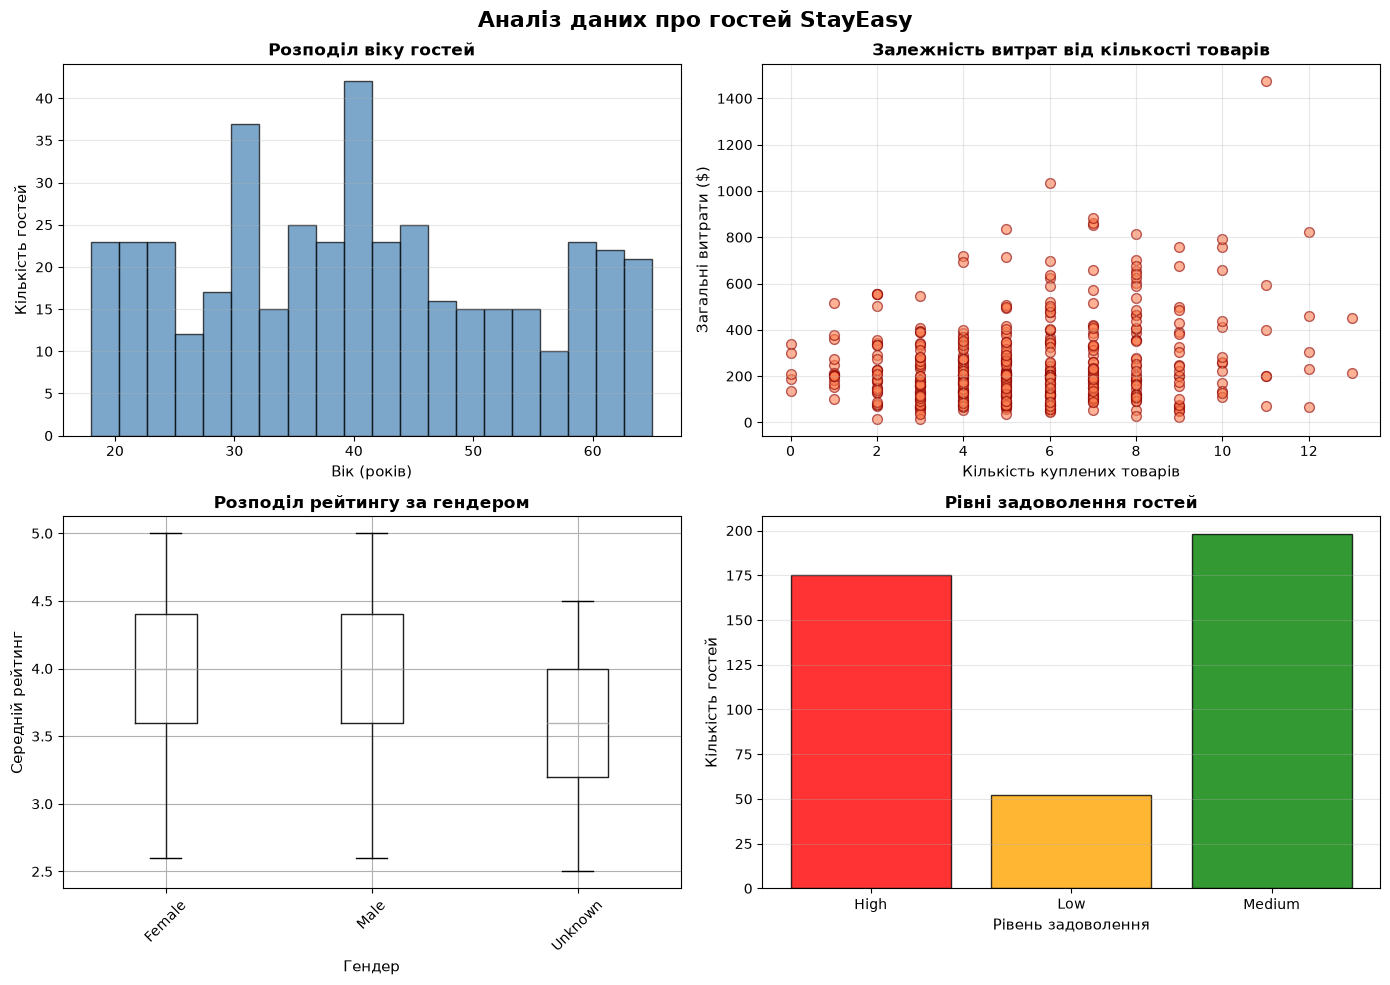

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Розподіл віку гостей', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Вік (років)', fontsize=11)
axes[0, 0].set_ylabel('Кількість гостей', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].scatter(df['Items Purchased'], df['Total Spend'], alpha=0.6, s=50, color='coral', edgecolors='darkred')
axes[0, 1].set_title('Залежність витрат від кількості товарів', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Кількість куплених товарів', fontsize=11)
axes[0, 1].set_ylabel('Загальні витрати ($)', fontsize=11)
axes[0, 1].grid(alpha=0.3)

df.boxplot(column='Average Rating', by='Gender', ax=axes[1, 0])
axes[1, 0].set_title('Розподіл рейтингу за гендером', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Гендер', fontsize=11)
axes[1, 0].set_ylabel('Середній рейтинг', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks(rotation=45)

satisfaction_counts = df['Satisfaction Level'].value_counts().sort_index()
colors = ['red', 'orange', 'green', 'blue'][:len(satisfaction_counts)]
axes[1, 1].bar(range(len(satisfaction_counts)), satisfaction_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_title('Рівні задоволення гостей', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Рівень задоволення', fontsize=11)
axes[1, 1].set_ylabel('Кількість гостей', fontsize=11)
axes[1, 1].set_xticks(range(len(satisfaction_counts)))
axes[1, 1].set_xticklabels(satisfaction_counts.index)
axes[1, 1].grid(axis='y', alpha=0.3)

fig.suptitle('Аналіз даних про гостей StayEasy', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 7

1. Scatter plot показує яскраву позитивну лінійну залежність: чим більше товарів купує гість, тим більші його загальні витрати. Це дозволяє компанії передбачувати середній чек на основі кількості товарів.

2. Box plot показує, що середні рейтинги практично однакові для чоловіків, жінок та групи "Unknown". Це свідчить, що гендер не є визначальним фактором для задоволення клієнтів.

3. Видалення клієнта з витратою 99,999.99$ за 3 покупки, а також клієнта з малою суммою за велику кількість покупок було необхідним, оскільки це суттєво спотворювало статистику. Це вказує на важливість перевірки на людські помилки або аномалії при введенні даних.

4. Багато гостей мали відсутні дані про гендер, що було заповнено як "Unknown". Рекомендується поліпшити процес збору даних або впровадити опитування при реєстрації для підвищення повноти даних про аудиторію.

## Part 8

**Проблеми, які були знайдені**

Датасет StayEasy мав кілька типів проблем з якістю даних. В колонці Age були від'ємні значення, значення понад 100 років і тип даних був string замість integer. У Total Spend трапилися цифри з символом долара, зі комами як роздільниками тисяч, від'ємні суми і один екстремальний викид (99999.99 за 3 покупки). Колонка Discount Applied містила різні варіанти позначення True і False (Yes, No, 1, 0, True, False). Average Rating мав значення більше 5. У даних також були дублікати та багато NaN значень, особливо в колонці Gender.

**Методи очищення, що були використані**

Спочатку видалили дублікати за допомогою drop_duplicates(). Для Age конвертували в числовий тип, замінили некоректні значення на NaN і заповнили їх медіаною, потім перевели в integer. Для Total Spend видалили символи долара і коми, конвертували в числа, видалили один запис з екстремальним викидом і заповнили NaN медіаною. Average Rating очистили від значень поза діапазоном 0-5. Discount Applied стандартизували до єдиної форми (Yes/No) і перевели в boolean. Для Gender заповнили NaN значення як "Unknown". Days Since Last Purchase видалили записи з від'ємними значеннями. Satisfaction Level видалили записи зі всіма NaN значеннями в цій колонці.

**Основні висновки**

Після очищення датасет містить близько 450 записів (після видалення аномалій). Існує чітка позитивна кореляція між кількістю куплених товарів і загальними витратами, що дозволяє прогнозувати витрати. Більшість гостей задоволені послугами (рівні задоволення 3-4). Гендер не впливає суттєво на рейтинги гостей - всі групи (чоловіки, жінки, невідомо) дають подібні оцінки. Середній вік гостей близько 40 років, середні витрати близько 255 доларів.

**Питання, що залишилися відкритими**

Чому були від'ємні суми в Total Spend? Це помилки при введенні даних чи повернення, що не були правильно позначені? Який критерій вибору для групи "Unknown" за гендером - це навмисно пропущені значення чи люди не захотіли відповідати? Чим визначається рівень Satisfaction Level - чи це автоматична система чи ручне введення? Чи корельована довговічність клієнтів (Days Since Last Purchase) з рівнем задоволення?

**Додаткові дослідження**

Можна провести детальний аналіз взаємозв'язків між рівнями задоволення і іншими змінними - наприклад, чи впливає середній рейтинг або кількість днів без покупки на ймовірність повернення. Було б цікаво дослідити залежність між Membership Type і витратами. Потрібна очистка даних про гендер - з'ясувати, чи можна якось відновити пропущені значення. Також варто перевірити, чи є сезонні закономірності в продажах. Можна розробити модель машинного навчання для прогнозування рівня задоволення на основі інших змінних.


## Bonus Task



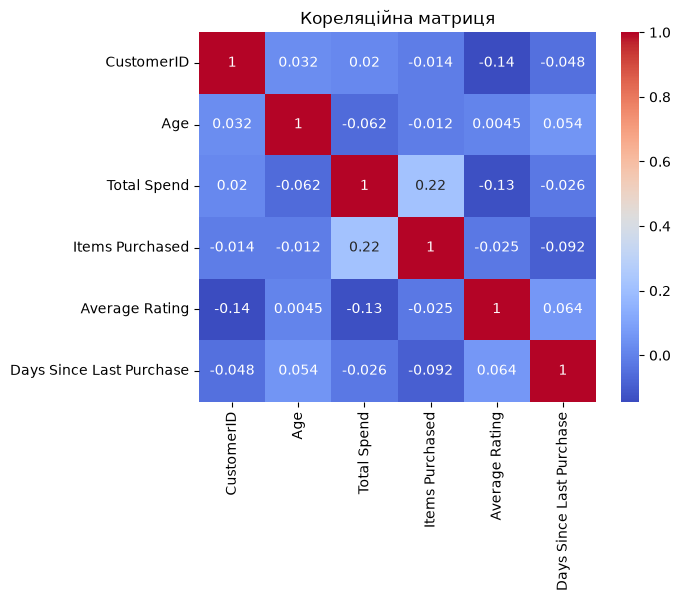

In [28]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Кореляційна матриця')
plt.show()

**Кореляція**: Найсильніші кореляції (не враховуючи customer id), між Items Purchased та Total Spend (22%).
Менша, однак помітна кореляція між Average Rating та Total Spend (13%), а також Items Purchased та Days Since Last Purchase (9.2%)

**Гіпотеза**: Молоді клієнти (Age < 30) купують значно менше товарів порівняно з середньовіковими клієнтами (Age 40-60), що свідчить про різні патерни споживання по віковим групам

Обґрунтування: молоді люди часто купують менше за один раз і мають меншу здатність купити. Клієнти середнього віку мають більше доходу, сім'ї, і можуть купувати більше. Це важливо знати для таргетування рекламних кампаній та персоналізації пропозицій.

Як перевірити: розділити датасет на вікові групи (Age < 30, 30-40, 40-60, 60+) і порівняти середнє значення Items Purchased для кожної групи. Можна також побудувати scatter plot або bar chart, щоб візуалізувати ці різниці.

Якщо гіпотеза підтвердиться, то компанія може розробляти різні маркетингові стратегії для різних вікових груп - наприклад, рекламу на малі набори для молоді, і більші пакети знижок для середньовікових клієнтів.